In [2]:
%pip install pandas
%pip install numpy
%pip install kagglehub
%pip install torch
%pip install torchinfo
%pip install tqdm
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\rounakbanik\the-movies-dataset\versions\7


In [3]:
import pandas as pd              
import numpy as np                   
import matplotlib.pyplot as plt
import seaborn as sns  
import ast      
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
from torchinfo import summary
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


In [4]:
print(torch.cuda.is_available()) # Should return True if CUDA is available 
print(torch.cuda.current_device()) # Should return the current CUDA device index 
print(torch.cuda.get_device_name(0)) # Should return the name of the CUDA device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

True
0
NVIDIA GeForce MX330


In [5]:
movies_metadata_path = path + '/movies_metadata.csv'
ratings_small_path = path + '/ratings_small.csv'

movies_metadata = pd.read_csv(movies_metadata_path)
ratings_small = pd.read_csv(ratings_small_path)



C:\Users\Admin\AppData\Local\Temp\ipykernel_32244\4262535036.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_metadata = pd.read_csv(movies_metadata_path)


In [5]:
movies_metadata_missings = movies_metadata.isnull().sum()
print(f"metadata: {movies_metadata_missings}")
ratings_small_missings = ratings_small.isnull().sum()
print(f"ratings: {ratings_small_missings}")

metadata: adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64
ratings: userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [6]:
movies_metadata['id'] = pd.to_numeric(movies_metadata['id'], errors='coerce')
merged_data = pd.merge(ratings_small, movies_metadata, left_on='movieId', right_on='id', how='inner')
merged_data = merged_data[merged_data['status'] == 'Released']
merged_data = merged_data[['userId', 'movieId', 'rating', 'genres', 'imdb_id', 'original_language', 'popularity', 'revenue', 'runtime', 'title', 'vote_average', 'vote_count']]

#print(merged_data['genres'])
#genres is a series of string, each string is similar to a dict
merged_data['genres'] = merged_data['genres'].apply(ast.literal_eval)
merged_data['genres_name'] = merged_data['genres'].apply(lambda row: [d['name'] for d in row])

genre_encoded = merged_data['genres_name'].str.join('|').str.get_dummies()
merged_data = pd.concat([merged_data, genre_encoded], axis=1)
merged_data.drop(['genres', 'genres_name'], axis=1, inplace=True)

print(merged_data.shape)
print(type(merged_data))

(44939, 31)
<class 'pandas.core.frame.DataFrame'>


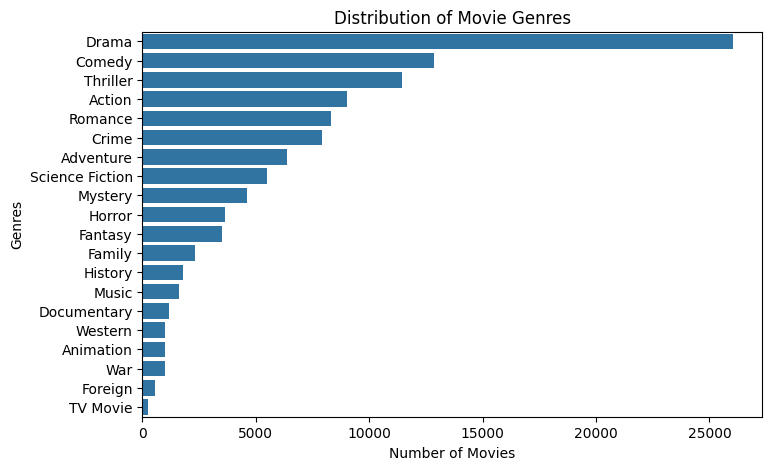

In [14]:
genres_count = genre_encoded.sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=genres_count.values, y=genres_count.index)
plt.title('Distribution of Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genres')
plt.show()


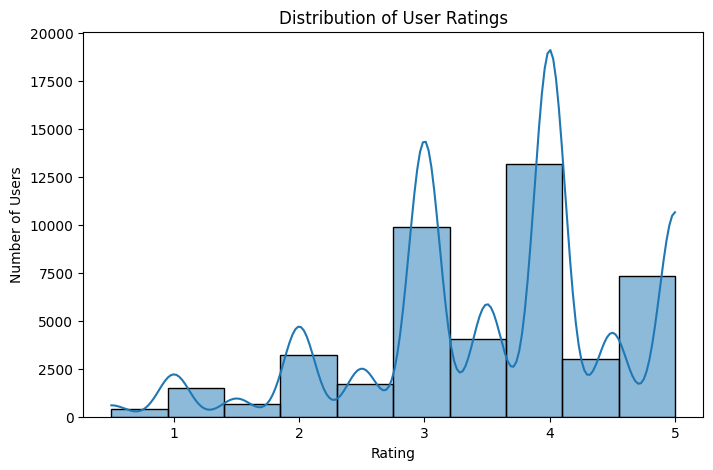

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(merged_data['rating'], bins=10, kde=True)
plt.title('Distribution of User Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Users')
plt.show()

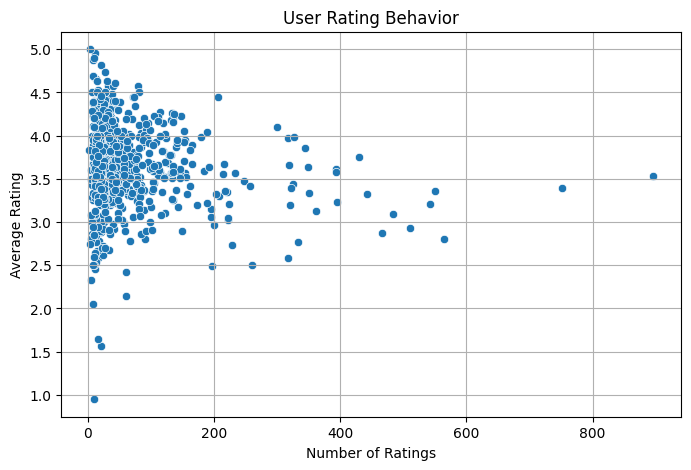

In [16]:
user_ratings = merged_data.groupby('userId')['rating'].agg(['mean', 'count'])
plt.figure(figsize=(8, 5))
sns.scatterplot(x=user_ratings['count'], y=user_ratings['mean'])
plt.title('User Rating Behavior')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()

In [23]:
merged_data['userId'] = merged_data['userId'].astype('int')
merged_data['movieId'] = merged_data['movieId'].astype('int')

num_users = merged_data['userId'].nunique()
num_movies = merged_data['movieId'].nunique()
print(num_movies)
print(num_users)

merged_data['rating'] = merged_data['rating'] / merged_data['rating'].max()

train, test = train_test_split(merged_data, test_size=0.2, random_state=42)

train_user_ids = train['userId'].values
train_movie_ids = train['movieId'].values
train_ratings = train['rating'].values

test_user_ids = test['userId'].values
test_movie_ids = test['movieId'].values
test_ratings = test['rating'].values

num_users = max(train_user_ids.max(), test_user_ids.max()) + 1
num_movies = max(train_movie_ids.max(), test_movie_ids.max()) + 1

print(num_movies)
print(num_users)
print(len(test_movie_ids))



2817
671
160719
672
8988


In [8]:
class MovieDataset(Dataset):
    def __init__(self, ratings_df, users_id, movies_id):
        self.users = torch.tensor(users_id, dtype=torch.int)
        self.movies = torch.tensor(movies_id, dtype=torch.int)
        self.ratings = torch.tensor(ratings_df, dtype=torch.float)
        
    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        return self.users[idx], self.movies[idx], self.ratings[idx]
        

In [9]:
class NNModel(nn.Module):
    def __init__(self, num_users, num_movies, embedding_dim=50, dropout_rate=0.2):
        super(NNModel, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.movie_embedding = nn.Embedding(num_movies, embedding_dim)

        self.fc1 = nn.Linear(embedding_dim * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 1)

        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

    def forward(self, user_input, movie_input):
        user_embedded = self.user_embedding(user_input).squeeze()
        movie_embedded = self.movie_embedding(movie_input).squeeze()

        concatenated = torch.cat([user_embedded, movie_embedded], dim=1)

        x = self.relu(self.fc1(concatenated))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)

        output = self.output(x)
        return output




In [12]:
import torch.nn.init as init

class MFModel(nn.Module):
    def __init__(self, num_users, num_movies, embedding_dim=50, dropout_rate=0.2):
        super(MFModel, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.movie_embedding = nn.Embedding(num_movies, embedding_dim)
        
        self.user_biases = nn.Embedding(num_users, 1)
        self.movie_biases = nn.Embedding(num_movies, 1)
        
        self.global_bias = nn.Parameter(torch.tensor(0.0))
        
        self.dropout = nn.Dropout(dropout_rate)
        
        self._init_weights()

    def _init_weights(self):
        init.xavier_uniform_(self.user_embedding.weight)
        init.xavier_uniform_(self.movie_embedding.weight)
        
        init.zeros_(self.user_biases.weight)
        init.zeros_(self.movie_biases.weight)
    
    def forward(self, user_input, movie_input):
        user_embedded = self.user_embedding(user_input) + torch.randn_like(self.user_embedding(user_input)) * 0.1
        movie_embedded = self.movie_embedding(movie_input) + torch.randn_like(self.movie_embedding(movie_input)) * 0.1
        
        user_embedded = self.dropout(user_embedded)
        movie_embedded = self.dropout(movie_embedded)
        
        user_bias = self.user_biases(user_input)
        movie_bias = self.movie_biases(movie_input)
        
        output = (user_embedded * movie_embedded).sum(dim=1, keepdim=True) + user_bias + movie_bias  
        return output
    
 

In [13]:
from tqdm import tqdm

class HybridModel(nn.Module):
    def __init__(self, mf_model, nn_model, mf_weight=0.5):
        super(HybridModel, self).__init__()
        self.mf_model = mf_model
        self.nn_model = nn_model
        self.mf_weight = nn.Parameter(torch.FloatTensor([mf_weight]))

    def forward(self, user_input, movie_input):
        mf_prediction = self.mf_model(user_input, movie_input)
        nn_prediction = self.nn_model(user_input, movie_input)

        mf_weight = torch.sigmoid(self.mf_weight)
        nn_weight = 1 - mf_weight
        
        blended_prediction = self.mf_weight * mf_prediction + nn_weight * nn_prediction
        
        return blended_prediction    
    
    def train_model(self, train_loader, valid_loader, device, epochs=10, lr=0.001):
        self.to(device)
        self.nn_model.to(device)
        self.mf_model.to(device)
        
        optimizer = optim.Adam([
            {'params': self.nn_model.parameters(), 'weight_decay': 1e-4},
            {'params': self.mf_model.parameters(), 'weight_decay': 1e-4},
            {'params': [self.mf_weight], 'lr': lr * 0.1}
        ], lr=lr)
        
        criterion = nn.MSELoss()
        best_valid_loss = float('inf')
        
        for epoch in range(epochs):
            self.train()
            train_loss = 0
            train_samples = 0
            
            for batch in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}'):
                tensor = torch.stack(batch).to(device)
                
                user_ids = tensor[0, :].long()
                movie_ids = tensor[1, :].long()
                ratings = tensor[2, :].float()
            
                # Forward pass
                predictions = self(user_ids, movie_ids)
                loss = criterion(predictions.squeeze(), ratings)
                
                # Backward pass
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item() * len(ratings)
                train_samples += len(ratings)
                
            avg_train_loss = np.sqrt(train_loss / train_samples)
            valid_loss = evaluate(self, valid_loader, criterion, device)
            
            print(f'\nEpoch {epoch + 1}/{epochs}:')
            print(f'Train RMSE: {avg_train_loss:.4f}')
            print(f'Valid RMSE: {valid_loss:.4f}')
            print(f'MF Weight: {torch.sigmoid(self.mf_weight).item():.4f}')
            print(f'NN Weight: {1 - torch.sigmoid(self.mf_weight).item():.4f}')
                
            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
                print(best_valid_loss)
                torch.save({
                    'hybrid_model': self.state_dict(),
                    'neural_network': self.nn_model.state_dict(),
                    'matrix_factorization': self.mf_model.state_dict(),
                    'mf_weight': self.mf_weight.item()
                }, 'best_models/best_hybrid_model.pth')
                    
                
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    total_samples = 0
        
    with torch.no_grad():
        for batch in data_loader:
            tensor = torch.stack(batch).to(device)
                
            user_ids = tensor[0, :].long()
            movie_ids = tensor[1, :].long()
            ratings = tensor[2, :].float()
                
            predictions = model(user_ids, movie_ids)
            loss = criterion(predictions.squeeze(), ratings)
                
            total_loss += loss.item() * len(ratings)
            total_samples += len(ratings)
                   
    return np.sqrt(total_loss / total_samples)        
        
        
        
    

In [43]:
# Train hybrid
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create DataLoader
train_dataset = MovieDataset(users_id=train_user_ids, movies_id=train_movie_ids, ratings_df=train_ratings)
test_dataset = MovieDataset(users_id=test_user_ids, movies_id=test_movie_ids, ratings_df=test_ratings)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True)

# Create hybrid model
mf_model = MFModel(num_users, num_movies, dropout_rate=0.3)
nn_model = NNModel(num_users, num_movies)

hybrid_model = HybridModel(mf_model=mf_model, nn_model=nn_model, mf_weight=0.5)
# hybrid_model.train_model(
#     train_loader=train_loader,
#     valid_loader=test_loader,
#     device=device,
#     epochs=20
# )


In [ ]:
# Checkpoint
checkpoint = torch.load('best_models/best_hybrid_model.pth')
hybrid_model.load_state_dict(checkpoint['hybrid_model'])
nn_model.load_state_dict(checkpoint['neural_network'])
mf_model.load_state_dict(checkpoint['matrix_factorization'])


<All keys matched successfully>

In [51]:
# Train Neural Network model
nn_model = NNModel(num_users, num_movies)
criterion = nn.MSELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.001)

nn_model = nn_model.to(device)

train_loader = DataLoader(train_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

epochs = 10
train_loss = 0
train_samples = 0
best_valid_loss = float('inf')

for epoch in range(epochs):
    for batch in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}'):
        tensor = torch.stack(batch).to(device)
                
        user_ids = tensor[0, :].long()
        movie_ids = tensor[1, :].long()
        ratings = tensor[2, :].float()
        
        # Forward pass
        predictions = nn_model(user_ids, movie_ids)
        loss = criterion(predictions.squeeze(), ratings)
                
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * len(ratings)
        train_samples += len(ratings)
                
    avg_train_loss = np.sqrt(train_loss / train_samples)
    valid_loss = evaluate(nn_model, test_loader, criterion, device)
            
    print(f'\nEpoch {epoch + 1}/{epochs}:')
    print(f'Train RMSE: {avg_train_loss:.4f}')
    print(f'Valid RMSE: {valid_loss:.4f}')  
    
    if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            print(best_valid_loss)
            torch.save({
                'neural_network': nn_model.state_dict(),
            }, 'best_models/best_neural_networks_model.pth')

Epoch 1/10: 100%|██████████| 281/281 [00:04<00:00, 59.48it/s]



Epoch 1/10:
Train RMSE: 0.2366
Valid RMSE: 0.2049
0.204935304202386


Epoch 2/10: 100%|██████████| 281/281 [00:04<00:00, 59.59it/s]



Epoch 2/10:
Train RMSE: 0.2154
Valid RMSE: 0.1965
0.19648086400131318


Epoch 3/10: 100%|██████████| 281/281 [00:04<00:00, 60.11it/s]


...


Epoch 8/10:
Train RMSE: 0.1828
Valid RMSE: 0.1951


Epoch 9/10: 100%|██████████| 281/281 [00:04<00:00, 59.93it/s]



Epoch 9/10:
Train RMSE: 0.1797
Valid RMSE: 0.1967


Epoch 10/10: 100%|██████████| 281/281 [00:04<00:00, 59.60it/s]



Epoch 10/10:
Train RMSE: 0.1768
Valid RMSE: 0.1997


In [45]:
def predict(model, user_id, movie_ids):
    model = model.to(device)
    model.eval()
    predictions = []
    
    with torch.no_grad():
        user_tensor = torch.tensor([user_id] * len(movie_ids), dtype=torch.long).to(device)
        movie_tensor = torch.tensor(movie_ids, dtype=torch.long).to(device)
        
        outputs = model(user_tensor, movie_tensor)
        
        for movie_id, pred in zip(movie_ids, outputs.cpu().numpy()):
            predictions.append((movie_id, float(pred)))
    
    return sorted(predictions, key=lambda x: x[1], reverse=True)



In [60]:
# Prepare input data
user_id = 3
rated_movies = merged_data[merged_data['userId'] == user_id][['movieId', 'rating', 'title']]
all_movie_ids = merged_data['movieId'].unique()
unseen_movie_ids = np.setdiff1d(all_movie_ids, rated_movies['movieId'])

In [61]:
# Load saved hybrid model
mf_model = MFModel(num_users, num_movies, dropout_rate=0.3)
nn_model = NNModel(num_users, num_movies)
hybrid_model = HybridModel(mf_model=mf_model, nn_model=nn_model, mf_weight=0.5)

model_path = 'best_models/best_hybrid_model.pth'
checkpoint = torch.load(model_path)

mf_model.load_state_dict(checkpoint['matrix_factorization'])
nn_model.load_state_dict(checkpoint['neural_network'])
hybrid_model.load_state_dict(checkpoint['hybrid_model'])
hybrid_model.mf_weight.data = torch.tensor([checkpoint['mf_weight']], dtype=torch.float32)

# Predict ratings
predicted_ratings_hybrid = predict(hybrid_model, user_id=user_id, movie_ids=unseen_movie_ids)
movie_predictions_hybrid = pd.DataFrame(predicted_ratings_hybrid, columns=['movieId', 'predicted_rating'])

# Load saved neural networks model
nn_model = NNModel(num_users, num_movies)
model_path = 'best_models/best_neural_networks_model.pth'
checkpoint = torch.load(model_path)
nn_model.load_state_dict(checkpoint['neural_network'])

# Predict ratings
predicted_ratings_nn = predict(nn_model, user_id=user_id, movie_ids=unseen_movie_ids)
movie_predictions_nn = pd.DataFrame(predicted_ratings_nn, columns=['movieId', 'predicted_rating'])


C:\Users\Admin\AppData\Local\Temp\ipykernel_32244\1730546040.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions.append((movie_id, float(pred)))


In [69]:
print(rated_movies.head(10)[['title', 'rating']])

top_movie_recommendations_hybrid = movie_predictions_hybrid.head(10)
top_movie_recommendations_hybrid = pd.merge(top_movie_recommendations_hybrid, movies_metadata[['id', 'title']], left_on='movieId', right_on='id')
print(top_movie_recommendations_hybrid[['title', 'predicted_rating']])

top_movie_recommendations_nn = movie_predictions_nn.head(10)
top_movie_recommendations_nn = pd.merge(top_movie_recommendations_nn, movies_metadata[['id', 'title']], left_on='movieId', right_on='id')
print(top_movie_recommendations_nn[['title', 'predicted_rating']])

                                   title  rating
456                    Three Colors: Red     0.8
2215  Terminator 3: Rise of the Machines     0.9
3240           A Nightmare on Elm Street     0.5
4516                  Once Were Warriors     0.6
5342                         Silent Hill     0.6
5759                    The Conversation     0.6
5955                             Solaris     0.6
6353                         The Killing     0.7
6396                          Live Flesh     0.6
6409            The Million Dollar Hotel     1.0
                     title  predicted_rating
0            Pandora's Box          0.883110
1              Match Point          0.871989
2             Frankenstein          0.861314
3          We're No Angels          0.857442
4                    Laura          0.852423
5          Hour of the Gun          0.852096
6             The Dreamers          0.850864
7  While You Were Sleeping          0.847340
8           Totally Blonde          0.847338
9         1

In [73]:
# Evaluation

def evaluate_model(test_loader, model):
    model.to(device)
    model.eval()
    pred_ratings = []
    
    with torch.no_grad():
        for user_ids, movie_ids, ratings in test_loader:
            user_ids = user_ids.to(device).long()
            movie_ids = movie_ids.to(device).long()
            ratings = ratings.to(device).float()
            
            outputs = model(user_ids, movie_ids)
            pred_ratings.extend(outputs.cpu().numpy())
            
    pred_ratings = np.array(pred_ratings)
    return pred_ratings

def compare_predictions(hybrid_preds, nn_preds, movie_genres=None):
    hybrid_preds = pd.DataFrame(hybrid_preds, columns=['movieId', 'predicted_ratings'])
    nn_preds = pd.DataFrame(nn_preds, columns=['movieId', 'predicted_ratings'])
    
    # systematic differences in how they rate certain types of movies
    if movie_genres is not None:
        hybrid_preds = pd.merge(hybrid_preds, merged_data['genres'], on='movieId', how='left')
        nn_preds = pd.merge(nn_preds, merged_data['genres'], on='movieId', how='left')
        
    print("\nDistribution and Characteristics of Predictions")
    print("\nRating Range and Spread:")
    hybrid_pred_ratings = hybrid_preds['predicted_ratings']
    nn_pred_ratings = nn_preds['predicted_ratings']
    print(f"Hybrid Model - Min: {hybrid_pred_ratings.min()}, Max: {hybrid_pred_ratings.max()}")
    print(f"Neural Network Model - Min: {nn_pred_ratings.min()}, Max: {nn_pred_ratings.max()}")
    
    print("\nMean and Standard Deviation:")
    print(f"Hybrid Model - Mean: {hybrid_pred_ratings.mean()}, Std: {hybrid_pred_ratings.std()}")    
    print(f"Neural Network Model - Mean: {nn_pred_ratings.mean()}, Std: {nn_pred_ratings.std()}")

In [77]:
# Basic evaluation for hybrid model

hybrid_pred_ratings = evaluate_model(test_loader, hybrid_model)
nn_pred_ratings = evaluate_model(test_loader, nn_model)

print(hybrid_pred_ratings)


[[0.57192236]
 [0.7185642 ]
 [0.7811296 ]
 ...
 [0.8590037 ]
 [0.765324  ]
 [0.9029363 ]]
